In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['prix'] = data.target

print(f"{df.shape[0]} maisons, {df.shape[1]} colonnes")
print(df.head())

20640 maisons, 9 colonnes
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude   prix  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [3]:
# Voir les colonnes disponibles
print(df.columns.tolist())

# Voir les statistiques de base
print(df.describe())

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'prix']
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude          prix  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      

In [4]:
# Séparer les données : X = ce qu'on utilise pour prédire, y = ce qu'on veut prédire
X = df.drop('prix', axis=1)  # toutes les colonnes sauf prix
y = df['prix']               # seulement le prix

# Couper en données d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entraînement : {X_train.shape[0]} maisons")
print(f"Test : {X_test.shape[0]} maisons")

Entraînement : 16512 maisons
Test : 4128 maisons


In [5]:
# Créer et entraîner le modèle
modele = LinearRegression()
modele.fit(X_train, y_train)

# Faire des prédictions sur les données de test
predictions = modele.predict(X_test)

# Mesurer la précision
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Erreur moyenne : {rmse:.2f} (en centaines de milliers de dollars)")
print(f"Soit environ : {rmse*100000:.0f} $")

Erreur moyenne : 0.75 (en centaines de milliers de dollars)
Soit environ : 74558 $


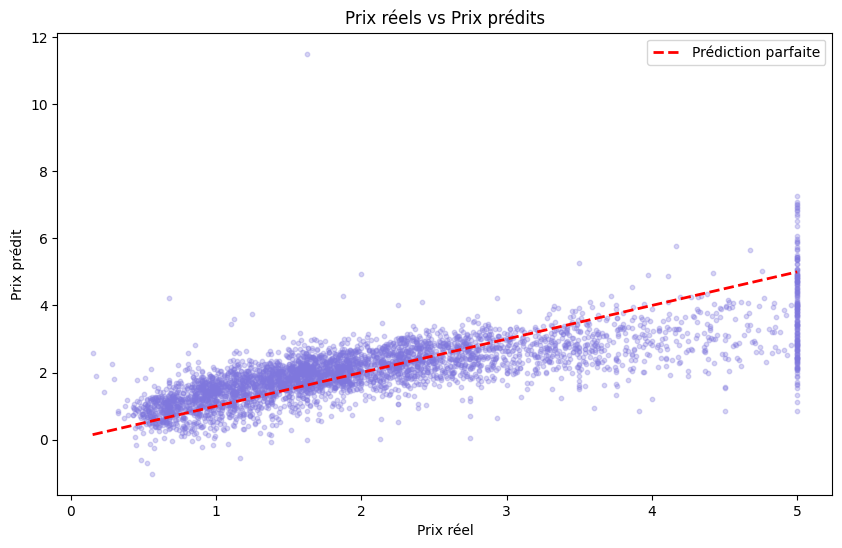

In [6]:
# Graphique — prix réels vs prix prédits
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.3, color='#7F77DD', s=10)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Prédiction parfaite')
plt.xlabel('Prix réel')
plt.ylabel('Prix prédit')
plt.title('Prix réels vs Prix prédits')
plt.legend()
plt.savefig('predictions.png', dpi=150)
plt.show()

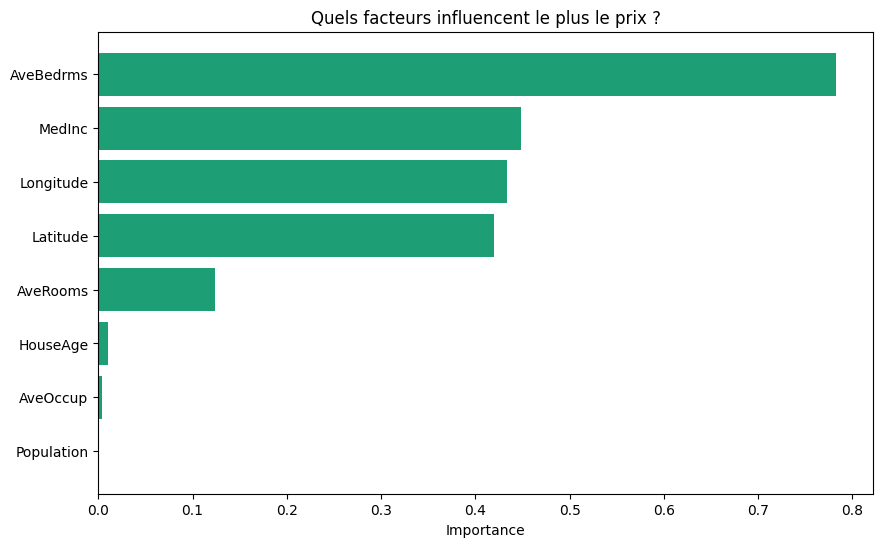

In [7]:
# Quelles colonnes influencent le plus le prix ?
importances = pd.DataFrame({
    'colonne': X.columns,
    'importance': abs(modele.coef_)
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importances['colonne'], importances['importance'], color='#1D9E75')
plt.title('Quels facteurs influencent le plus le prix ?')
plt.xlabel('Importance')
plt.savefig('importances.png', dpi=150)
plt.show()